In [1]:
import pandas as pd
import numpy as np

# **Timestamp Object:**
- Time stamp refers to particular momenrts in time.

## **Creating** timestamp object:

In [2]:
print(pd.Timestamp('2023/1/5'))
print(type(pd.Timestamp('2023/1/5')))

2023-01-05 00:00:00
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [3]:
#variations
pd.Timestamp('2023-01-05')
pd.Timestamp('2023,01,05')

Timestamp('2023-05-01 00:00:00')

In [4]:
#only year
pd.Timestamp('2023')

Timestamp('2023-01-01 00:00:00')

In [5]:
# using text:
pd.Timestamp('5th January 2023')

Timestamp('2023-01-05 00:00:00')

In [6]:
# providing time also:
pd.Timestamp('2023/1/5 12:30:00')
pd.Timestamp('5th January 2023 9:23 PM')

Timestamp('2023-01-05 21:23:00')

## Using **datetime module:**

In [7]:
import datetime as dt

In [8]:
dt.datetime(2023, 1, 5, 12, 30, 0)

datetime.datetime(2023, 1, 5, 12, 30)

## Creating a Timestamp using **Python Datetime:**

In [9]:
x= pd.Timestamp(dt.datetime(2023, 1, 5, 12, 30, 0))

In [10]:
x.year
x.month
x.day
x.hour
x.minute

30

# Why seperate object to handle date and time when python already has datetime?
- Syntax wise datetime is very convinient.
- But the performance takes a hit while working with large datasets.
- That's why numpy team added a set of native time series data to NumPy.
- The datetime64 dtype encodes dates as a 64 bit integer, and thus allow arrays of dates to represent very compactly.

---
# **DatetimeIndex** Object:

- It is a collection of Pandas timestamp in a NumPy array.

---

## **Creating** a DatetimeIndex Object:
1. Using strings:

In [11]:
t= pd.DatetimeIndex(['2023/1/1', '2022/1/1', '2022/1/1'])

In [12]:
t[0] #returns a timestamp object

Timestamp('2023-01-01 00:00:00')

2. Using Pythons Datetime:

In [13]:
pd.DatetimeIndex([dt.datetime(2023, 1, 5, 12, 30, 0),
                 dt.datetime(2022, 1, 5, 12, 30, 0),
                 dt.datetime(2022, 1, 5, 12, 30, 0)
                 ])

DatetimeIndex(['2023-01-05 12:30:00', '2022-01-05 12:30:00',
               '2022-01-05 12:30:00'],
              dtype='datetime64[ns]', freq=None)

3. Using Pandas Timestamp:

In [14]:
pd.DatetimeIndex([pd.Timestamp(2023/1/5),
                 pd.Timestamp(2022/1/5),
                 pd.Timestamp(2022/1/5)
                 ])

DatetimeIndex(['1970-01-01 00:00:00.000000404',
               '1970-01-01 00:00:00.000000404',
               '1970-01-01 00:00:00.000000404'],
              dtype='datetime64[ns]', freq=None)

---

### Using datetimeIndex as **series index:**

In [15]:
dt_index= pd.DatetimeIndex([pd.Timestamp(2023/1/5),
                 pd.Timestamp(2022/1/5),
                 pd.Timestamp(2022/1/5)
                 ])

In [16]:
pd.Series([1,2,3], index=dt_index)

1970-01-01 00:00:00.000000404    1
1970-01-01 00:00:00.000000404    2
1970-01-01 00:00:00.000000404    3
dtype: int64

---

### **`.date_range()`** :

- Generates timestamps in a given range.

In [17]:
pd.date_range(start='2023/1/5', end='2023/1/10')

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10'],
              dtype='datetime64[ns]', freq='D')

Alternate days in a given range:

In [18]:
pd.date_range(start='2023/1/5', end='2024/1/10', freq='2D')  # Alternate days in a given range

DatetimeIndex(['2023-01-05', '2023-01-07', '2023-01-09', '2023-01-11',
               '2023-01-13', '2023-01-15', '2023-01-17', '2023-01-19',
               '2023-01-21', '2023-01-23',
               ...
               '2023-12-23', '2023-12-25', '2023-12-27', '2023-12-29',
               '2023-12-31', '2024-01-02', '2024-01-04', '2024-01-06',
               '2024-01-08', '2024-01-10'],
              dtype='datetime64[ns]', length=186, freq='2D')

- `freq=` parameter:
    - by default= 'D' : generates each day in betweeen the range.
    - '2D' : generates every 2nd day in range.
    - '3D' : genrates every 3rd day in range, and so on...
    - 'B' : generates business day in range(Mon to Fri)
    - 'W' : generates 1 day im a week.
    - '2W' : generates 2 day im a week.
    - 'W-THU' : generates one day in per week which is thursday in range.
    - '2W-THU' : generates one day per two weeks which is thursday in range.
    - 'H' : generates one timestamp perhour.
    - 'ME' : generates one timestamp for evry month end.

In [19]:
pd.date_range(start='2023/1/5', end='2024/1/10', freq='B')

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-09', '2023-01-10',
               '2023-01-11', '2023-01-12', '2023-01-13', '2023-01-16',
               '2023-01-17', '2023-01-18',
               ...
               '2023-12-28', '2023-12-29', '2024-01-01', '2024-01-02',
               '2024-01-03', '2024-01-04', '2024-01-05', '2024-01-08',
               '2024-01-09', '2024-01-10'],
              dtype='datetime64[ns]', length=265, freq='B')

In [20]:
pd.date_range(start='2023/1/5', end='2024/1/10', freq='W')
pd.date_range(start='2023/1/5', end='2024/1/10', freq='W-THU')

DatetimeIndex(['2023-01-05', '2023-01-12', '2023-01-19', '2023-01-26',
               '2023-02-02', '2023-02-09', '2023-02-16', '2023-02-23',
               '2023-03-02', '2023-03-09', '2023-03-16', '2023-03-23',
               '2023-03-30', '2023-04-06', '2023-04-13', '2023-04-20',
               '2023-04-27', '2023-05-04', '2023-05-11', '2023-05-18',
               '2023-05-25', '2023-06-01', '2023-06-08', '2023-06-15',
               '2023-06-22', '2023-06-29', '2023-07-06', '2023-07-13',
               '2023-07-20', '2023-07-27', '2023-08-03', '2023-08-10',
               '2023-08-17', '2023-08-24', '2023-08-31', '2023-09-07',
               '2023-09-14', '2023-09-21', '2023-09-28', '2023-10-05',
               '2023-10-12', '2023-10-19', '2023-10-26', '2023-11-02',
               '2023-11-09', '2023-11-16', '2023-11-23', '2023-11-30',
               '2023-12-07', '2023-12-14', '2023-12-21', '2023-12-28',
               '2024-01-04'],
              dtype='datetime64[ns]', freq='W-T

In [21]:
pd.date_range(start='2023/1/5', end='2024/1/10', freq='ME')

DatetimeIndex(['2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30',
               '2023-05-31', '2023-06-30', '2023-07-31', '2023-08-31',
               '2023-09-30', '2023-10-31', '2023-11-30', '2023-12-31'],
              dtype='datetime64[ns]', freq='ME')

-Using `periods=` instead of `end=`:

In [22]:
pd.date_range(start='2023/1/5', periods=10)  # Generates 10 dates starting from '2023/1/5'

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-14'],
              dtype='datetime64[ns]', freq='D')

---
## **`to_datetime()`** function:

converts an existing object to a timestamp/ datetime object:

In [23]:
s=pd.Series(['2023/1/5', '2022/1/5', '2021/1/5'])
pd.to_datetime(s).dt.year

0    2023
1    2022
2    2021
dtype: int32

### Handling Errors:

In [24]:
s= pd.Series(['2023/1/5', '2022/130/5', '2021/1/5'])
pd.to_datetime(s, errors='coerce')  # Converts invalid dates to NaT (Not a Time)

0   2023-01-05
1          NaT
2   2021-01-05
dtype: datetime64[ns]

---

# **Real World Case Study Using datetime:**

In [25]:
df= pd.read_csv('C:/Users/anike/OneDrive/Desktop/Learning Pandas/Datasets/Session-22/expense_data.csv')
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [26]:
df['Date']= pd.to_datetime(df['Date'])

Now, Use dt accessor to extract date components like year, month, day, etc.

In [27]:
df['Date'].dt.year

0      2022
1      2022
2      2022
3      2022
4      2022
       ... 
272    2021
273    2021
274    2021
275    2021
276    2021
Name: Date, Length: 277, dtype: int32

<Axes: >

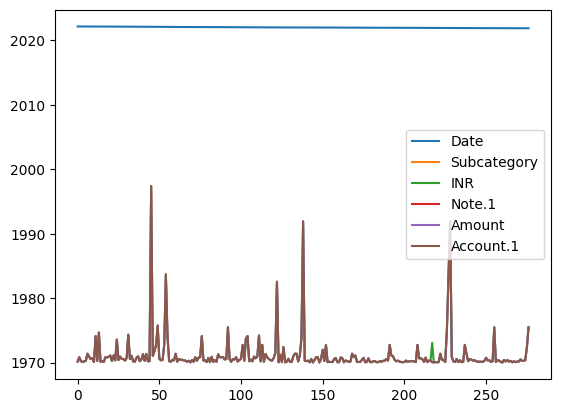

In [28]:
df.plot()

Day name wise/ month wise bar chart

<Axes: xlabel='day_name'>

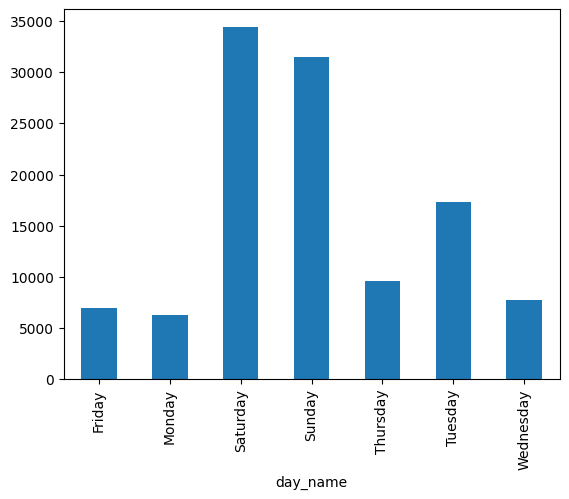

In [29]:
df['day_name']= df['Date'].dt.day_name()
df.groupby('day_name')['INR'].sum().plot(kind='bar')

<Axes: xlabel='month_name'>

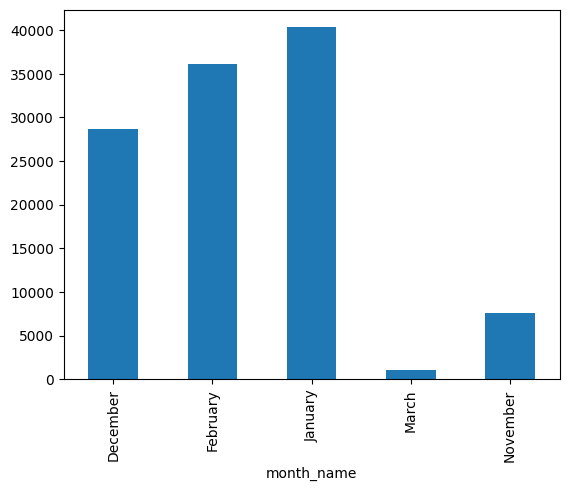

In [30]:
#month wise
df['month_name']= df['Date'].dt.month_name()
df.groupby('month_name')['INR'].sum().plot(kind='bar')